In [1]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.stats import pearsonr

In [2]:
# Fig.2(A)
data3 = pd.read_pickle('G_ripple_data3.pkl')
data3.head(2)

,group,delta_C_ITE
0,winner,-0.024711
1,winner,0.122059


In [3]:
from scipy.stats import ttest_ind
group1_data = data3.loc[data3['group'] == 'coauthor', 'delta_C_ITE']
group2_data = data3.loc[data3['group'] == 'winner', 'delta_C_ITE']
t_statistic, p_value = ttest_ind(group1_data, group2_data)
print(f'T-Statistic: {t_statistic}')
print(f'P-Value: {p_value}') ## p<0.001 The average of the delta_C_ITE for winners and coauthors are significantly different

T-Statistic: -10.44894491406126
P-Value: 1.5042095756383336e-25


In [4]:
aggregations = {'mean': ('delta_C_ITE', np.mean),
    '95% CI': ('delta_C_ITE', lambda x: 1.96 * np.std(x) / np.sqrt(len(x)))}
result3 = data3.groupby(["group"]).agg(**aggregations)
result3['group'] = result3.index 
result3

/var/tmp/pbs.3899146.hpc-pbs-sched1/ipykernel_1463448/113471745.py:3: FutureWarning: The provided callable <function mean at 0x146ad43cf560> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  result3 = data3.groupby(["group"]).agg(**aggregations)


,mean,95% CI,group
group,,,
coauthor,0.051199,0.001467,coauthor
winner,0.110179,0.008324,winner


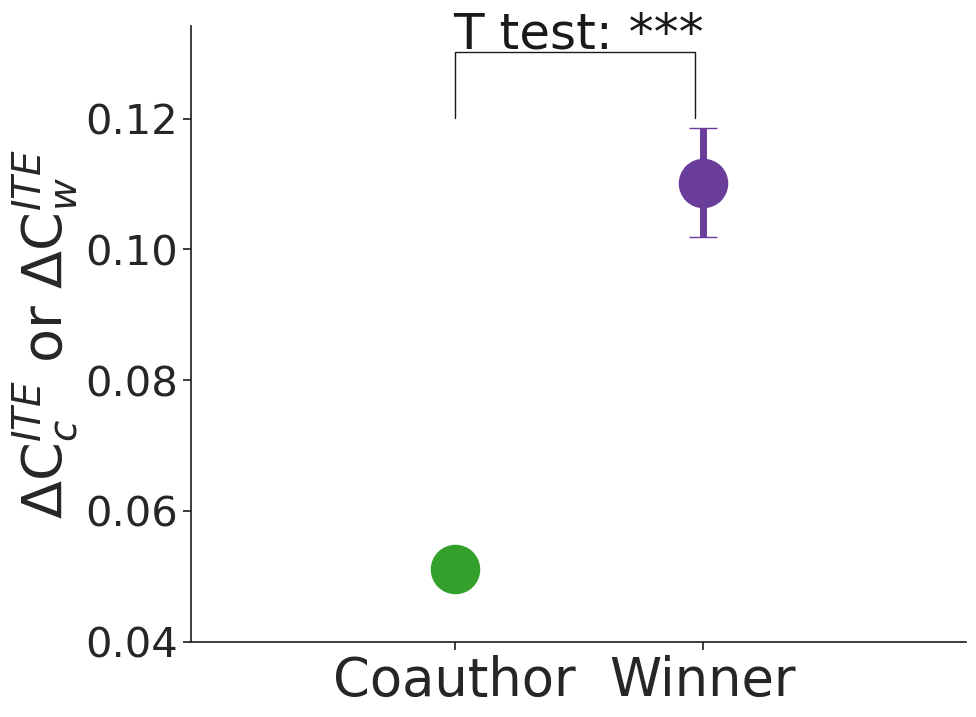

In [5]:
sns.set(font_scale=1.5)
sns.set(style="ticks")
fig, ax = plt.subplots(figsize=(10,8))
##coauthor
plt.scatter(0.34, 0.051199, marker='o', s=1200, edgecolors='#33A02C', facecolors='#33A02C', zorder=0)
plt.errorbar(0.34, 0.051199, yerr=0.001467, color='#33A02C', capsize=10,elinewidth=5)
## winner
plt.scatter(0.66, 0.110179, marker='o', s=1200, edgecolors='#6A3D9A', facecolors='#6A3D9A', zorder=0)
plt.errorbar(0.66, 0.110179, yerr=0.008324, color='#6A3D9A', capsize=10,elinewidth=5)
x1, x2 = 0.34, 0.65
ax.plot([x1, x1, x2, x2], [0.110179+0.01, 0.110179+0.02,0.110179+0.02, 0.110179+0.01], lw=1, c="k")
p_value_cov = 0.001  
stars = "***" 
ax.text(0.5, 0.133, f"T test: {stars}", ha='center', va='center', color="k", fontsize=36)
plt.ylabel(r"ΔC$^{ITE}_{c}$ or ΔC$^{ITE}_{w}$", fontsize=40)
plt.xticks([0.34, 0.66], ['Coauthor', 'Winner'], fontsize=38)
plt.yticks(fontsize=30)
plt.xlim(0, 1)
plt.ylim(0.040)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

In [6]:
### Fig.2(B)
data4 = pd.read_pickle('G_ripple_data4.pkl')
data4.head(2)

,delta_C_winner,C_b_winner,interval,group
0,-0.225462,0.700511,"[0.598, 0.748)",winner
1,0.530747,0.447650,"[0.299, 0.449)",winner


In [7]:
correlation = pearsonr(data4['C_b_winner'], data4['delta_C_winner'])
correlation

PearsonRResult(statistic=np.float64(0.32450070460087843), pvalue=np.float64(1.1746705172368105e-85))

In [8]:
aggregations = {
    'mean': ('delta_C_winner', np.mean),
    '95% CI': ('delta_C_winner', lambda x: 1.96 * np.std(x) / np.sqrt(len(x)))}
result4 = data4.groupby(["interval"]).agg(**aggregations)
result4

/var/tmp/pbs.3899146.hpc-pbs-sched1/ipykernel_1463448/699949001.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result4 = data4.groupby(["interval"]).agg(**aggregations)
/var/tmp/pbs.3899146.hpc-pbs-sched1/ipykernel_1463448/699949001.py:4: FutureWarning: The provided callable <function mean at 0x146ad43cf560> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  result4 = data4.groupby(["interval"]).agg(**aggregations)


,mean,95% CI
interval,,
"[0.0, 0.15)",0.095389,0.052732
"[0.15, 0.299)",0.054475,0.025248
"[0.299, 0.449)",0.133158,0.025159
"[0.449, 0.598)",0.178415,0.028900
"[0.598, 0.748)",0.243368,0.037584
"[0.748, 0.897)",0.359788,0.051237
"[0.897, 1.047)",0.399664,0.072153
"[1.047, 1.196)",0.584215,0.090053
"[1.196, 1.346)",0.639683,0.125684


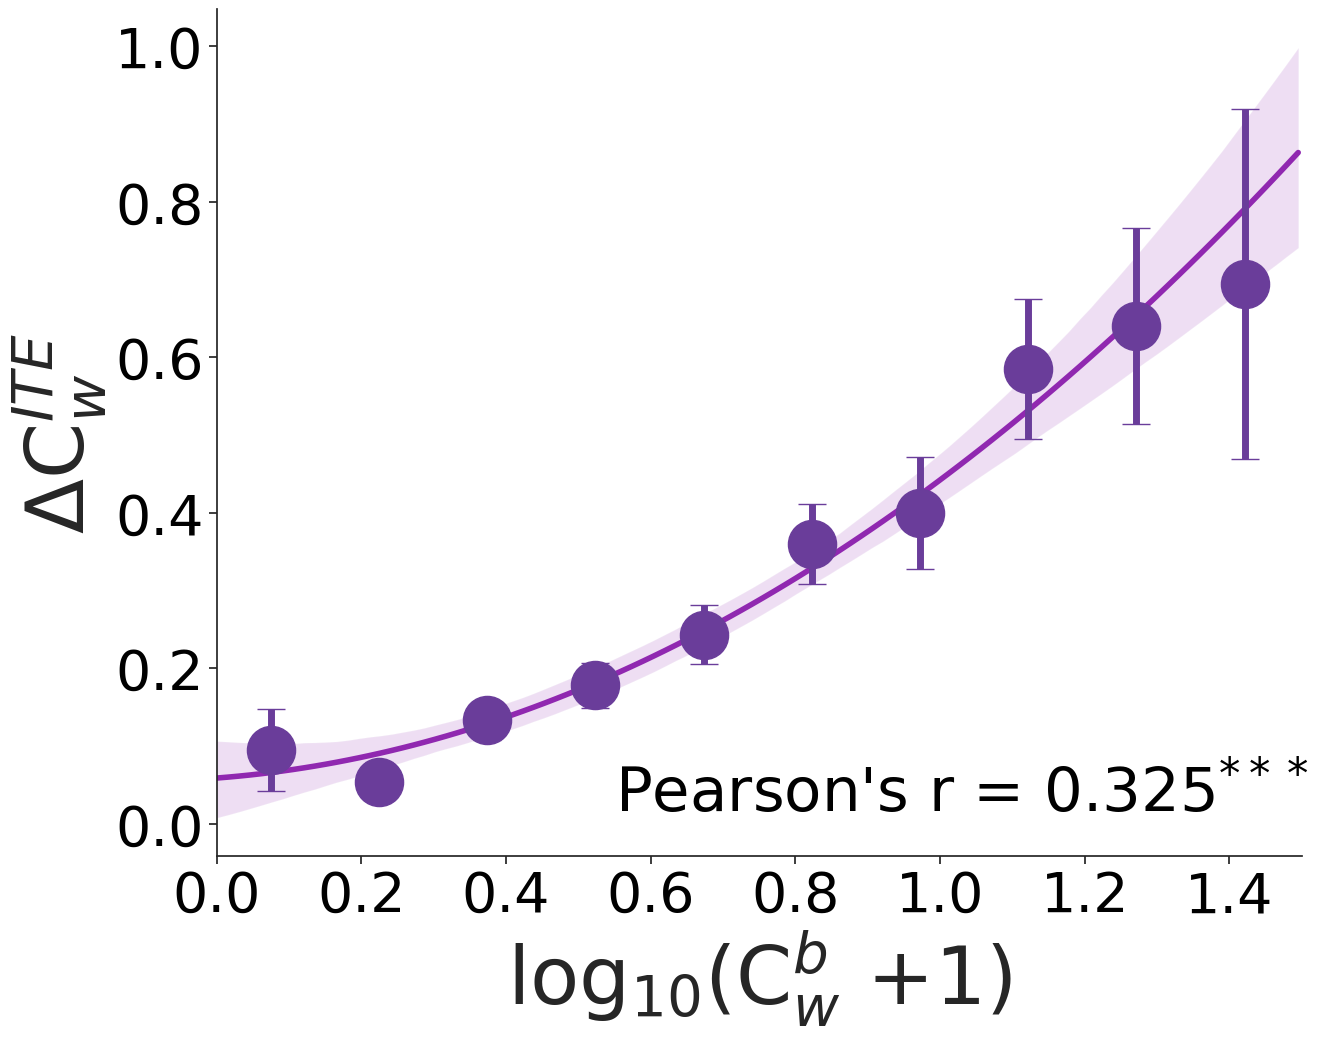

In [9]:
sns.set(font_scale=1.5)
sns.set(style="ticks")
fig, ax = plt.subplots(figsize=(14,11))
sns.regplot(x='C_b_winner', y='delta_C_winner', data=data4, ci=95, order=2,x_bins=np.arange(0.00, 1.50, 10),line_kws={"color": "#9028B0","linewidth": 4},ax=ax, scatter=False)

plt.scatter(0.075, 0.095389, marker='o', s=1200, edgecolors='#6A3D9A', facecolors='#6A3D9A', zorder=2)
plt.errorbar(0.075, 0.095389, yerr=0.052732, color='#6A3D9A', capsize=10,elinewidth=5)
plt.scatter(0.2245, 0.054475, marker='o', s=1200, edgecolors='#6A3D9A', facecolors='#6A3D9A', zorder=2)
plt.errorbar(0.2245, 0.054475, yerr=0.025248, color='#6A3D9A', capsize=10,elinewidth=5)
plt.scatter(0.374, 0.133158, marker='o', s=1200, edgecolors='#6A3D9A', facecolors='#6A3D9A', zorder=2)
plt.errorbar(0.374, 0.133158, yerr=0.025159, color='#6A3D9A', capsize=10,elinewidth=5)
plt.scatter(0.5235, 0.178415, marker='o', s=1200, edgecolors='#6A3D9A', facecolors='#6A3D9A', zorder=2)
plt.errorbar(0.5235, 0.178415, yerr=0.028900, color='#6A3D9A', capsize=10,elinewidth=5)
plt.scatter(0.673, 0.243368, marker='o', s=1200, edgecolors='#6A3D9A', facecolors='#6A3D9A', zorder=2)
plt.errorbar(0.673, 0.243368, yerr=0.037584, color='#6A3D9A', capsize=10,elinewidth=5)
plt.scatter(0.8225, 0.359788, marker='o', s=1200, edgecolors='#6A3D9A', facecolors='#6A3D9A', zorder=2)
plt.errorbar(0.8225, 0.359788, yerr=0.051237, color='#6A3D9A', capsize=10,elinewidth=5)
plt.scatter(0.972, 0.399664, marker='o', s=1200, edgecolors='#6A3D9A', facecolors='#6A3D9A', zorder=2)
plt.errorbar(0.972, 0.399664, yerr=0.072153, color='#6A3D9A', capsize=10,elinewidth=5)
plt.scatter(1.1215, 0.584215, marker='o', s=1200, edgecolors='#6A3D9A', facecolors='#6A3D9A', zorder=2)
plt.errorbar(1.1215, 0.584215, yerr=0.090053, color='#6A3D9A', capsize=10,elinewidth=5)
plt.scatter(1.271, 0.639683, marker='o', s=1200, edgecolors='#6A3D9A', facecolors='#6A3D9A', zorder=2)
plt.errorbar(1.271, 0.639683, yerr=0.125684, color='#6A3D9A', capsize=10,elinewidth=5)
plt.scatter(1.4215, 0.694206, marker='o', s=1200, edgecolors='#6A3D9A', facecolors='#6A3D9A', zorder=2)
plt.errorbar(1.4215, 0.694206, yerr=0.225227, color='#6A3D9A', capsize=10,elinewidth=5)

plt.xlim(0.00, 1.50)
plt.xlabel(r"log$_{10}$(C$^{b}_{w}$ +1)", fontsize=58)
plt.ylabel(r"ΔC$^{ITE}_{w}$",fontsize=58)
plt.xticks(fontsize=40,color='black')
plt.yticks(fontsize=40,color='black')
text = r"Pearson's r = 0.325$^{***}$"
plt.text(0.55,0, text, fontsize=44, color='black', ha='left', va='bottom', bbox=dict(facecolor='white', alpha=0))
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

In [10]:
### Fig.2(C)
data5 = pd.read_pickle('G_ripple_data5.pkl')
data5.head(2)

,delta_C_coathor,C_b_coauthor,interval,group
0,-0.059827,0.245650,"[0.13, 0.26)",coauthor
1,-0.188137,0.474494,"[0.39, 0.52)",coauthor


In [11]:
correlation = pearsonr(data5['C_b_coauthor'], data5['delta_C_coathor'])
correlation

PearsonRResult(statistic=np.float64(0.0609488344571756), pvalue=np.float64(5.859715788749073e-159))

In [12]:
aggregations = {
    'mean': ('delta_C_coathor', np.mean),
    '95% CI': ('delta_C_coathor', lambda x: 1.96 * np.std(x) / np.sqrt(len(x)))}
result5 = data5.groupby(["interval"]).agg(**aggregations)
result5

/var/tmp/pbs.3899146.hpc-pbs-sched1/ipykernel_1463448/3786972192.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result5 = data5.groupby(["interval"]).agg(**aggregations)
/var/tmp/pbs.3899146.hpc-pbs-sched1/ipykernel_1463448/3786972192.py:4: FutureWarning: The provided callable <function mean at 0x146ad43cf560> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  result5 = data5.groupby(["interval"]).agg(**aggregations)


,mean,95% CI
interval,,
"[0.0, 0.13)",0.056701,0.005059
"[0.13, 0.26)",0.048210,0.005267
"[0.26, 0.39)",0.052245,0.004411
"[0.39, 0.52)",0.069887,0.004447
"[0.52, 0.65)",0.093637,0.005185
"[0.65, 0.78)",0.115126,0.006644
"[0.78, 0.91)",0.125739,0.009050
"[0.91, 1.04)",0.132566,0.012967
"[1.04, 1.17)",0.141538,0.018737


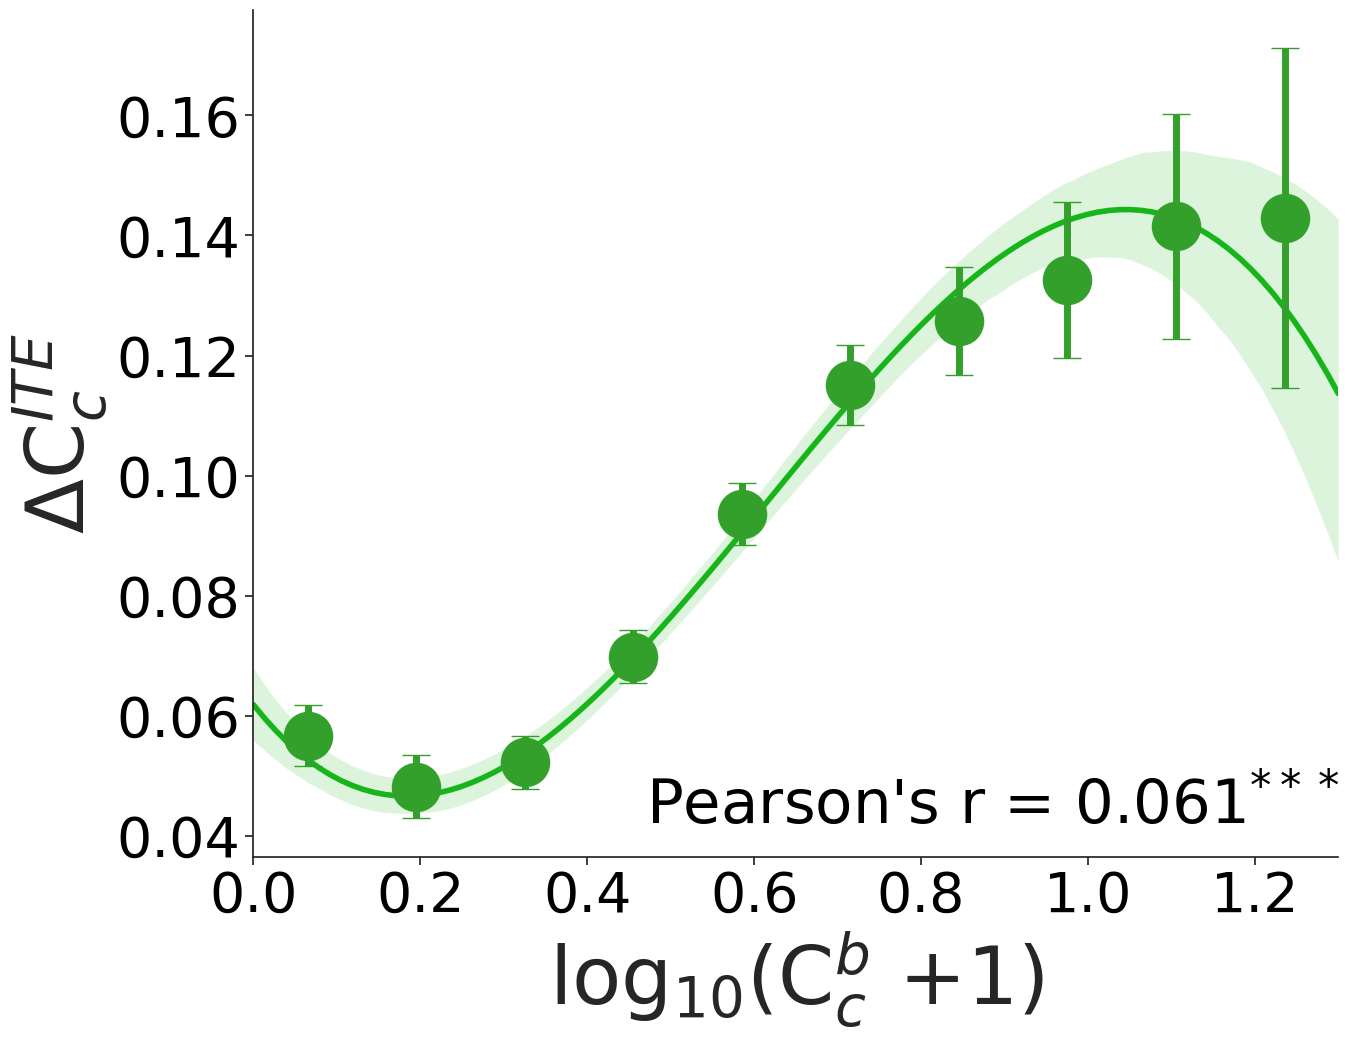

In [13]:
sns.set(font_scale=1.5)
sns.set(style="ticks")
fig, ax = plt.subplots(figsize=(14,11))
sns.regplot(x='C_b_coauthor', y='delta_C_coathor', data=data5, ci=95, order=3,line_kws={"color": "#16B61A","linewidth": 4},ax=ax,scatter=False)

plt.scatter(0.065, 0.056701, marker='o', s=1200, edgecolors='#33A02C', facecolors='#33A02C', zorder=2)
plt.errorbar(0.065, 0.056701, yerr=0.005059, color='#33A02C', capsize=10,elinewidth=5)
plt.scatter(0.195, 0.048210, marker='o', s=1200, edgecolors='#33A02C', facecolors='#33A02C', zorder=2)
plt.errorbar(0.195, 0.048210, yerr=0.005267, color='#33A02C', capsize=10,elinewidth=5)
plt.scatter(0.325, 0.052245, marker='o', s=1200, edgecolors='#33A02C', facecolors='#33A02C', zorder=2)
plt.errorbar(0.325, 0.052245, yerr=0.004411, color='#33A02C', capsize=10,elinewidth=5)
plt.scatter(0.455, 0.069887, marker='o', s=1200, edgecolors='#33A02C', facecolors='#33A02C', zorder=2)
plt.errorbar(0.455, 0.069887, yerr=0.004447, color='#33A02C', capsize=10,elinewidth=5)
plt.scatter(0.585, 0.093637, marker='o', s=1200, edgecolors='#33A02C', facecolors='#33A02C', zorder=2)
plt.errorbar(0.585, 0.093637, yerr=0.005185, color='#33A02C', capsize=10,elinewidth=5)
plt.scatter(0.715, 0.115126, marker='o', s=1200, edgecolors='#33A02C', facecolors='#33A02C', zorder=2)
plt.errorbar(0.715, 0.115126, yerr=0.006644, color='#33A02C', capsize=10,elinewidth=5)
plt.scatter(0.845, 0.125739, marker='o', s=1200, edgecolors='#33A02C', facecolors='#33A02C', zorder=2)
plt.errorbar(0.845, 0.125739, yerr=0.009050, color='#33A02C', capsize=10,elinewidth=5)
plt.scatter(0.975, 0.132566, marker='o', s=1200, edgecolors='#33A02C', facecolors='#33A02C', zorder=2)
plt.errorbar(0.975, 0.132566, yerr=0.012967, color='#33A02C', capsize=10,elinewidth=5)
plt.scatter(1.105, 0.141538, marker='o', s=1200, edgecolors='#33A02C', facecolors='#33A02C', zorder=2)
plt.errorbar(1.105, 0.141538, yerr=0.018737, color='#33A02C', capsize=10,elinewidth=5)
plt.scatter(1.2355, 0.142872, marker='o', s=1200, edgecolors='#33A02C', facecolors='#33A02C', zorder=2)
plt.errorbar(1.2355,0.142872, yerr=0.028287, color='#33A02C', capsize=10,elinewidth=5)

plt.xlim(0, 1.30)
plt.xlabel(r"log$_{10}$(C$^{b}_{c}$ +1)",fontsize=58)
plt.ylabel(r"ΔC$^{ITE}_{c}$",fontsize=58)
plt.xticks(fontsize=40,color='black')
plt.yticks(fontsize=40,color='black')
text = r"Pearson's r = 0.061$^{***}$"
plt.text(0.47,0.04, text, fontsize=44, color='black', ha='left', va='bottom', bbox=dict(facecolor='white', alpha=0))
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

In [14]:
### Fig.2(D)
data6 = pd.read_pickle('G_ripple_data6.pkl')
data6.head(2)

,WinnerID,delta_C_coauthor,delta_C_winner,interval
0,1,0.037365,-0.225462,"[-0.386, -0.188)"
1,2,0.298759,0.530747,"[0.406, 0.604)"


In [15]:
correlation = pearsonr(data6['delta_C_winner'], data6['delta_C_coauthor'])
correlation

PearsonRResult(statistic=np.float64(0.2710118486771961), pvalue=np.float64(5.0019637053042754e-51))

In [16]:
aggregations = {'mean': ('delta_C_coauthor', np.mean),
    '95% CI': ('delta_C_coauthor', lambda x: 1.96 * np.std(x) / np.sqrt(len(x)))}
result6 = data6.groupby(["interval"]).agg(**aggregations)
result6

/var/tmp/pbs.3899146.hpc-pbs-sched1/ipykernel_1463448/3107323266.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result6 = data6.groupby(["interval"]).agg(**aggregations)
/var/tmp/pbs.3899146.hpc-pbs-sched1/ipykernel_1463448/3107323266.py:3: FutureWarning: The provided callable <function mean at 0x146ad43cf560> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  result6 = data6.groupby(["interval"]).agg(**aggregations)


,mean,95% CI
interval,,
"[-0.386, -0.188)",0.048342,0.032542
"[-0.188, 0.0102)",0.035886,0.015275
"[0.0102, 0.208)",0.076111,0.014884
"[0.208, 0.406)",0.094498,0.019408
"[0.406, 0.604)",0.138962,0.029394
"[0.604, 0.802)",0.163873,0.040205
"[0.802, 1.0)",0.256520,0.055681
"[1.0, 1.198)",0.294857,0.082526
"[1.198, 1.396)",0.247597,0.098510


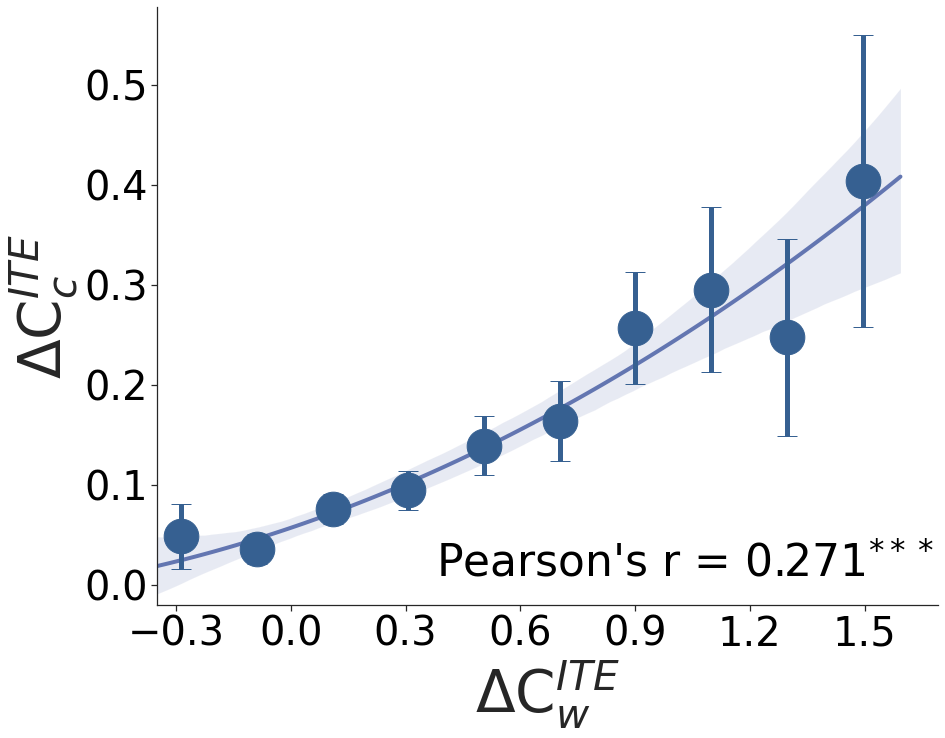

In [17]:
sns.set(font_scale=1.5)
sns.set(style="ticks")
fig, ax = plt.subplots(figsize=(14,11))
sns.regplot(x='delta_C_winner', y='delta_C_coauthor', data=data6,ci=95, order=2,line_kws={"color": '#6376B1',"linewidth": 4},ax=ax, scatter=False)

plt.scatter(-0.287, 0.048342, marker='o', s=1200, edgecolors="#366091", facecolors="#366091", zorder=2)
plt.errorbar(-0.287, 0.048342, yerr=0.032542, color="#366091", capsize=10,elinewidth=5)
plt.scatter(-0.0889, 0.035886, marker='o', s=1200, edgecolors="#366091", facecolors="#366091", zorder=2)
plt.errorbar(-0.0889, 0.035886, yerr=0.015275, color="#366091", capsize=10,elinewidth=5)
plt.scatter(0.1091, 0.076111, marker='o', s=1200, edgecolors="#366091", facecolors="#366091", zorder=2)
plt.errorbar(0.1091, 0.076111, yerr=0.014884, color="#366091", capsize=10,elinewidth=5)
plt.scatter(0.307, 0.094498, marker='o', s=1200, edgecolors="#366091", facecolors="#366091", zorder=2)
plt.errorbar(0.307, 0.094498, yerr=0.019408, color="#366091", capsize=10,elinewidth=5)
plt.scatter(0.505, 0.138962, marker='o', s=1200, edgecolors="#366091", facecolors="#366091", zorder=2)
plt.errorbar(0.505, 0.138962, yerr=0.029394, color="#366091", capsize=10,elinewidth=5)
plt.scatter(0.703, 0.163873, marker='o', s=1200, edgecolors="#366091", facecolors="#366091", zorder=2)
plt.errorbar(0.703, 0.163873, yerr=0.040205, color="#366091", capsize=10,elinewidth=5)
plt.scatter(0.901, 0.256520, marker='o', s=1200, edgecolors="#366091", facecolors="#366091", zorder=2)
plt.errorbar(0.901, 0.256520, yerr=0.055681, color="#366091", capsize=10,elinewidth=5)
plt.scatter(1.099, 0.294857, marker='o', s=1200, edgecolors="#366091", facecolors="#366091", zorder=2)
plt.errorbar(1.099, 0.294857, yerr=0.082526, color="#366091", capsize=10,elinewidth=5)
plt.scatter(1.297, 0.247597, marker='o', s=1200, edgecolors="#366091", facecolors="#366091", zorder=2)
plt.errorbar(1.297, 0.247597, yerr=0.098510, color="#366091", capsize=10,elinewidth=5)
plt.scatter(1.496, 0.403401, marker='o', s=1200, edgecolors="#366091", facecolors="#366091", zorder=2)
plt.errorbar(1.496, 0.403401, yerr=0.146030, color="#366091", capsize=10,elinewidth=5)

plt.xlim(-0.35, None)
plt.ylim(-0.02, None)
plt.xlabel(r"ΔC$^{ITE}_{w}$", fontsize=58)
plt.ylabel(r"ΔC$^{ITE}_{c}$",fontsize=58)
plt.xticks(np.arange(-0.3, 1.7, 0.3),fontsize=40,color='black')
plt.yticks(fontsize=40,color='black')
text = r"Pearson's r = 0.271$^{***}$"
plt.text(0.38,0, text, fontsize=44, color='black', ha='left', va='bottom', bbox=dict(facecolor='white', alpha=0))
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()